# PIPELINE STEPS : VALIDATED STEPS ONLY

### Important for auto reloading any changes in files in VS CODE withouting restarting kernel

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

project_root = os.path.abspath("../..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

### For auto correcting execution path for notebook

In [2]:
import os
print(os.getcwd())
import sys
import os

project_root = os.path.abspath("./..")

if project_root not in sys.path:
    sys.path.append(project_root)

print(project_root)

/home/arun/Desktop/AIProjects/rag-evaluation-framework/experiments
/home/arun/Desktop/AIProjects/rag-evaluation-framework


## Stage 1 : Imports

In [3]:
from src_v2.parsers.docling_parser import (
    DoclingParser
)

from src_v2.parsers.markdown_section_parser import (
    MarkdownSectionParser
)
from src_v2.preprocessing.formula_cleaner import (
    FormulaCleaner
)
from src_v2.parsers.level_inference import (
    LevelInference
)
from src_v2.normalization.section_flattener import (
    SectionFlattener
)

/home/arun/Desktop/AIProjects/rag-evaluation-framework/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Stage : Corpus Collection

#### PDF Collection

In [9]:
from pathlib import Path

sources = []

PDF_DIR = (
    Path(project_root)
    / "data"
    / "documents"
)

for pdf in PDF_DIR.glob("*.pdf"):

    sources.append(
        str(pdf)
    )

sources.extend(
    [
        "https://arxiv.org/pdf/1706.03762.pdf",
        "https://arxiv.org/pdf/1810.04805.pdf",
        "https://arxiv.org/pdf/2005.14165.pdf",
        "https://arxiv.org/pdf/2004.04906.pdf",
        "https://arxiv.org/pdf/2007.00808.pdf",
        "https://arxiv.org/pdf/2010.00904.pdf",
        "https://arxiv.org/pdf/2005.11401.pdf",
        "https://arxiv.org/pdf/2312.10997.pdf",
        "https://arxiv.org/pdf/2402.19473.pdf",
        "https://arxiv.org/pdf/2410.12837.pdf",
        "https://arxiv.org/pdf/2104.08663.pdf",
        "https://arxiv.org/pdf/2212.09741.pdf",
        "https://arxiv.org/pdf/2506.18027.pdf",
        "https://arxiv.org/pdf/2410.15944.pdf"
           
    ]
)

print(
    f"{len(sources)} sources found"
)

for source in sources:

    print(source)

27 sources found
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/lbdl.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Transformer_Architecture_Guide.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Agentic_AI_and_Orchestration_Brief.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/vectors_and_embeddings.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Generative_AI_Fundamentals.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Vectorless_RAG_Technical_Report.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/knowledge_graphs_agentic_ai.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/LangGraph_Comprehensive_Guide.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Guardrails_and_Evals_in_Agentic_AI.pdf
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/L

## Stage 2: Parsing source documents using Docling

In [16]:
docling=DoclingParser()
all_markdowns = []
for source in sources:
    print("=" * 80)
    print("Processing:")
    print(source)
    try:
        markdown = docling.parse(
            source
        )
        all_markdowns.append(
            markdown
        )
        print(
            f"Success | Length: {len(markdown)}"
        )
    except Exception as e:
        print(
            f"Failed: {e}"
        )

Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/lbdl.pdf


[INFO] 2026-06-14 02:10:23,698 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-14 02:10:23,704 [RapidOCR] download_file.py:60: File exists and is valid: /home/arun/Desktop/AIProjects/rag-evaluation-framework/.venv/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-14 02:10:23,705 [RapidOCR] main.py:57: Using /home/arun/Desktop/AIProjects/rag-evaluation-framework/.venv/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-14 02:10:23,781 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-14 02:10:23,783 [RapidOCR] download_file.py:60: File exists and is valid: /home/arun/Desktop/AIProjects/rag-evaluation-framework/.venv/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-14 02:10:23,783 [RapidOCR] main.py:57: Using /home/arun/Desktop/AIProjects/rag-evaluation-framework/.venv/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile

Success | Length: 158466
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Transformer_Architecture_Guide.pdf
Success | Length: 7181
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Agentic_AI_and_Orchestration_Brief.pdf
Success | Length: 8699
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/vectors_and_embeddings.pdf
Success | Length: 7324
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Generative_AI_Fundamentals.pdf
Success | Length: 6076
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/Vectorless_RAG_Technical_Report.pdf
Success | Length: 8833
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/knowledge_graphs_agentic_ai.pdf
Success | Length: 8988
Processing:
/home/arun/Desktop/AIProjects/rag-evaluation-framework/data/documents/LangGraph_Comprehensive_Guide.pdf
Success | Length: 6091
Proces

[WARNING] 2026-06-14 02:13:07,450 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!
[WARNING] 2026-06-14 02:13:07,660 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!
[WARNING] 2026-06-14 02:13:07,784 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!


Success | Length: 136085
Processing:
https://arxiv.org/pdf/2410.12837.pdf
Success | Length: 52418
Processing:
https://arxiv.org/pdf/2104.08663.pdf
Success | Length: 115027
Processing:
https://arxiv.org/pdf/2212.09741.pdf
Success | Length: 90594
Processing:
https://arxiv.org/pdf/2506.18027.pdf
Success | Length: 49785
Processing:
https://arxiv.org/pdf/2410.15944.pdf
Success | Length: 70700


In [17]:
print(
    "Sources:",
    len(sources)
)

print(
    "Markdown Documents:",
    len(all_markdowns)
)

Sources: 27
Markdown Documents: 27


## Storage : Caching parsed documents for future retrieval

In [187]:
from src_v2.cache import (
    save_parsed_documents
)

save_parsed_documents(
    all_markdowns
)

Saved -> data/cache/parsed_documents.pkl


## Fetch Cache : Cached parsed documents : cache layer

In [4]:
from src_v2.cache import (
    parsed_documents_exist,
    load_parsed_documents
)
if parsed_documents_exist():
    parsed_documents = (
        load_parsed_documents()
    )
else:
    print(
        "No cached parsed documents found"
    )

Loaded -> data/cache/parsed_documents.pkl


In [5]:
all_markdowns=parsed_documents

In [6]:
print(
    "Markdown Documents:",
    len(all_markdowns)
)

Markdown Documents: 27


## Stage 3: Process (string :text in markdown format) obtained from Docling parsing for LATEX errors

In [7]:
cleaner = FormulaCleaner()

all_cleaned_markdowns = []

for markdown in all_markdowns:

    cleaned = cleaner.process_markdown(
        markdown
    )

    all_cleaned_markdowns.append(
        cleaned
    )

print(
    f"Processed {len(all_cleaned_markdowns)} documents"
)

Processed 27 documents


## Stage 4: Creating a document(markdown parser needs 2 inputs a string(markdown text) and A Document(random)

In [10]:
from src_v2.models.document import Document
documents = []
for idx, source in enumerate(sources):
    title = (
        source.split("/")[-1]
        .replace(".pdf", "")
    )
    doc = Document(
        doc_id=f"doc_{idx}",
        title=title,
        source_type="pdf",
        source_path=source
    )
    documents.append(
        doc
    )
print(
    f"{len(documents)} documents created"
)

27 documents created


### This parser parses the string to remove any markdown format in the string

In [11]:
parser = MarkdownSectionParser()
parsed_documents = []
for document, markdown in zip(
    documents,
    all_cleaned_markdowns
):
    parsed_doc = parser.parse(
        markdown,
        document
    )
    parsed_documents.append(
        parsed_doc
    )
print(
    f"{len(parsed_documents)} documents parsed"
)

27 documents parsed


## Stage 5: Level Inferencing constructs levels in a documents based on a set of rules

In [12]:
inferencer = LevelInference()
inferred_documents = []
for document in parsed_documents:

    inferred_doc = inferencer.infer(
        document
    )
    inferred_documents.append(
        inferred_doc
    )
print(
    f"{len(inferred_documents)} documents inferred"
)

27 documents inferred


## Stage 6: Hierarchy builder builds the hierarchy based on the levels we created

In [13]:
from src_v2.parsers.hierarchy_builder import (
    HierarchyBuilder
)
builder = HierarchyBuilder()
hierarchy_documents = []

for document in inferred_documents:
    hierarchy_doc = builder.build(
        document
    )
    hierarchy_documents.append(
        hierarchy_doc
    )
    
print(
    f"{len(hierarchy_documents)} documents processed"
)

27 documents processed


## Stage 7: Convert heirarchical document tree into flat list while preserving hierarchy information in the path(metadata)

In [14]:
flattener = SectionFlattener()
all_flattened_sections = []

for document in hierarchy_documents:
    flattened = flattener.flatten(
        document
    )
    all_flattened_sections.extend(
        flattened
    )

print(
    "Flattened sections:",
    len(all_flattened_sections)
)

Flattened sections: 672


## Stage 8: Section Chunker -Section aware + Structure (Tables/Formula) Aware Chunking

In [15]:
import importlib

import src_v2.chunking.section_chunker

importlib.reload(
    src_v2.chunking.section_chunker
)

<module 'src_v2.chunking.section_chunker' from '/home/arun/Desktop/AIProjects/rag-evaluation-framework/src_v2/chunking/section_chunker.py'>

In [16]:
from src_v2.chunking.section_chunker import (
    SectionChunker
)
chunker = SectionChunker()
all_chunks = []

for document in hierarchy_documents:
    flattened_sections = flattener.flatten(
        document
    )
    chunks = chunker.chunk(
        document=document,
        sections=flattened_sections
    )
    all_chunks.extend(
        chunks
    )

print(
    f"{len(all_chunks)} chunks created"
)

1777 chunks created


In [17]:
print(
    "Documents:",
    len(hierarchy_documents)
)
print(
    "Chunks:",
    len(all_chunks)
)
print(
    "Avg Chunks Per Document:",
    len(all_chunks) / len(hierarchy_documents)
)

Documents: 27
Chunks: 1777
Avg Chunks Per Document: 65.81481481481481


### Cell for Validating Chunks before embedding creation

In [18]:
import importlib

import src_v2.validation.chunk_auditor

importlib.reload(
    src_v2.validation.chunk_auditor
)

from src_v2.validation.chunk_auditor import (
    ChunkAuditor
)

print("ChunkAuditor reloaded successfully.")

ChunkAuditor reloaded successfully.


In [19]:
from src_v2.validation.chunk_auditor import(ChunkAuditor)
auditor = ChunkAuditor()
auditor.audit(
    all_chunks
)

CHUNK AUDIT REPORT

Chunk Types
----------------------------------------
parent_section: 637
table_fragment: 187
section_fragment: 953

Size Statistics
----------------------------------------
Min: 3
Max: 52144
Average: 1657.31
Chunks >5000 chars: 70
Non-parent chunks >5000 chars: 0

Largest Chunks
----------------------------------------
Type: parent_section
Size: 9982
Section: Contents
Type: parent_section
Size: 6136
Section: 4.6 Normalizing layers
Type: parent_section
Size: 6852
Section: Synthesis
Type: parent_section
Size: 5469
Section: 8.2 Quantization
Type: parent_section
Size: 11323
Section: Bibliography
Type: parent_section
Size: 5990
Section: Index
Type: parent_section
Size: 10915
Section: 6.2 Model Variations
Type: parent_section
Size: 7109
Section: References
Type: parent_section
Size: 6972
Section: 4.2 SQuAD v1.1
Type: parent_section
Size: 11361
Section: References
Type: parent_section
Size: 13208
Section: 1 Introduction
Type: parent_section
Size: 7390
Section: 2 Approach
T

In [20]:
too_large = [
    c
    for c in all_chunks
    if (
        c.chunk_type != "parent_section"
        and len(c.content) > 5000
    )
]

print(
    "Violations:",
    len(too_large)
)

for c in too_large:

    print(
        len(c.content),
        c.chunk_type,
        c.section_title
    )

Violations: 0


In [21]:
import importlib

import src_v2.embedding.ollama_embedding_generator

importlib.reload(
    src_v2.embedding.ollama_embedding_generator
)

<module 'src_v2.embedding.ollama_embedding_generator' from '/home/arun/Desktop/AIProjects/rag-evaluation-framework/src_v2/embedding/ollama_embedding_generator.py'>

## Embedding generator starts here 

In [22]:
from src_v2.embedding.ollama_embedding_generator import OllamaEmbeddingGenerator

In [23]:
print(len(all_chunks))

1777


In [24]:
embedding_chunks = [
    chunk
    for chunk in all_chunks
    if chunk.chunk_type != "parent_section"
]

print(
    len(embedding_chunks)
)

1140


In [25]:
embedding_generator=OllamaEmbeddingGenerator()
chunk_embeddings = (
    embedding_generator.generate(
        embedding_chunks
    )
)
print(
    len(chunk_embeddings)
)

Processed 50/1140 chunks
Processed 100/1140 chunks
Processed 150/1140 chunks
Processed 200/1140 chunks
Processed 250/1140 chunks
Processed 300/1140 chunks
Processed 350/1140 chunks
Processed 400/1140 chunks
Processed 450/1140 chunks
Processed 500/1140 chunks
Processed 550/1140 chunks
Processed 600/1140 chunks
Processed 650/1140 chunks
Processed 700/1140 chunks
Processed 750/1140 chunks
Processed 800/1140 chunks
Processed 850/1140 chunks
Processed 900/1140 chunks
Processed 950/1140 chunks
Processed 1000/1140 chunks
Processed 1050/1140 chunks
Processed 1100/1140 chunks
Processed 1140/1140 chunks
1140


### Emeddings Storage phase

In [26]:
from src_v2.vectorstore import (
    ChromaStore
)
store = ChromaStore()
store.reset()
store.add_embeddings(
    chunk_embeddings
)

print(
    "Stored:",
    store.count()
)

Stored: 1140


# Retrieval Phase : Complete variety of retrieval techniques implemented

#### validation to check what is returned

## Reloading new modules

In [34]:
def clear_project_modules(
    prefix="src_v2"
):
    import sys

    for module in list(sys.modules):
        if module.startswith(prefix):
            del sys.modules[module]

    print(
        f"Cleared modules under {prefix}"
    )

# usage clear_project_modules("src_v2.retrieval")

In [35]:
clear_project_modules("src_v2.retrieval")

Cleared modules under src_v2.retrieval


In [36]:
clear_project_modules("src_v2.retrieval.dense")

Cleared modules under src_v2.retrieval.dense


In [27]:
queries = [
    "What is retrieval augmented generation?",
    "How do language models use external knowledge?",
    "What is dense retrieval?",
    "What causes hallucination in LLMs?",
    "hallucination",
    "hallucinations",
    "What is query transformation?"
]

In [28]:

from src_v2.retrieval.dense import (
    DenseRetriever
)

dense_retriever = DenseRetriever(
    embedding_model=embedding_generator.model,
    vector_store=store
)

In [29]:

for query in queries:

    print()
    print("=" * 100)
    print(query)
    print("=" * 100)

    results = dense_retriever.retrieve(
        query=query,
        k=5
    )

    for result in results:

        print(
            result.chunk.section_title,
            "|",
            round(result.score, 4)
        )


What is retrieval augmented generation?
6. Future Research Directions for Retrieval-Augmented Generation (RAG) | 0.652
A. RAG Foundations | 0.4426
I. INTRODUCTION | 0.4364
6. Future Research Directions for Retrieval-Augmented Generation (RAG) | 0.4053
B. RAG Enhancements | 0.3914

How do language models use external knowledge?
I. INTRODUCTION | 0.4378
7 Related Work | 0.4374
1 Introduction | 0.394
1 Introduction | 0.3932
Contributions | 0.3853

What is dense retrieval?
7 RELATED WORK | 0.6533
7 RELATED WORK | 0.5861
2 PRELIMINARIES | 0.5531
C. Retriever | 0.5228
A. Retrieval Source | 0.4885

What causes hallucination in LLMs?
4. Recent Advancement in the field: | 0.3384
G Details of Task Phrasing and Specifications | 0.2908
H Document Length Preference for Dense Retrieval System | 0.2686
A.3 IMPACT OF ASYNCHRONOUS GAP | 0.2593
H Document Length Preference for Dense Retrieval System | 0.2546

hallucination
4. Recent Advancement in the field: | 0.1906
6.2 Image classification | 0.0323
6

## Trick to solve stale import issues

In [71]:
def clear_project_modules(
    prefix="src_v2"
):
    import sys

    for module in list(sys.modules):
        if module.startswith(prefix):
            del sys.modules[module]

    print(
        f"Cleared modules under {prefix}"
    )

# usage clear_project_modules("src_v2.retrieval")

In [44]:
clear_project_modules("src_v2.retrieval")

Cleared modules under src_v2.retrieval


In [45]:
clear_project_modules("src_v2.retrieval.config")

Cleared modules under src_v2.retrieval.config


In [46]:
clear_project_modules("src_v2.retrieval.bm25")

Cleared modules under src_v2.retrieval.bm25


In [30]:
from src_v2.retrieval.bm25 import (
    BM25Retriever
)

bm25_retriever = BM25Retriever(
    embedding_chunks
)

print("BM25 initialized")

BM25 initialized


In [31]:

for query in queries:

    print()
    print("=" * 100)
    print(query)
    print("=" * 100)

    results = bm25_retriever.retrieve(
        query=query,
        k=5
    )

    for result in results:

        print(
            result.chunk.section_title,
            "|",
            round(result.score, 4)
        )


What is retrieval augmented generation?
2.3 Understanding the Role of PDFs in RAG | 6.7089
4. Recent Advancement in the field: | 6.6396
A. Background | 6.3475
6. Future Research Directions for Retrieval-Augmented Generation (RAG) | 6.3424
4. Recent Advancement in the field: | 6.1728

How do language models use external knowledge?
1 Introduction | 12.9226
1 Introduction | 10.6771
A. RAG for Text | 10.588
I. INTRODUCTION | 10.3253
A. Retrieval Source | 9.6467

What is dense retrieval?
5 Results and Analysis | 8.34
A.5 CASE STUDIES | 6.0518
A.3 IMPACT OF ASYNCHRONOUS GAP | 5.9245
G Details of Task Phrasing and Specifications | 5.6299
C. Retriever | 5.5582

What causes hallucination in LLMs?
H Document Length Preference for Dense Retrieval System | 10.8516
A.3 IMPACT OF ASYNCHRONOUS GAP | 8.2328
G Details of Task Phrasing and Specifications | 8.2237
A. Background | 7.9565
I. INTRODUCTION | 7.8656

hallucination
C. RAG for Knowledge | 5.4102
A. RAG for Text | 4.4294
A. Naive RAG | 4.3361
S

## Hybrid Retriever being implemented

In [72]:
clear_project_modules("src_v2.retrieval.hybrid")

Cleared modules under src_v2.retrieval.hybrid


In [73]:
from src_v2.retrieval.hybrid import (
    HybridRetriever
)

hybrid_retriever = (
    HybridRetriever(
        dense_retriever=dense_retriever,
        bm25_retriever=bm25_retriever
    )
)

print(
    "Hybrid initialized"
)

Hybrid initialized


In [74]:
for query in queries:

    print()
    print("=" * 100)
    print(query)
    print("=" * 100)

    results = hybrid_retriever.retrieve(
        query=query,
        k=5
    )

    for result in results:

        print(
            result.chunk.section_title,
            "|",
            round(result.score, 4)
        )


What is retrieval augmented generation?
6. Future Research Directions for Retrieval-Augmented Generation (RAG) | 0.871
2.3 Understanding the Role of PDFs in RAG | 0.5
4. Recent Advancement in the field: | 0.4756
A. Background | 0.3728
4. Recent Advancement in the field: | 0.3113

How do language models use external knowledge?
I. INTRODUCTION | 0.8068
1 Introduction | 0.6483
7 Related Work | 0.4986
1 Introduction | 0.3366
1 Introduction | 0.3335

What is dense retrieval?
7 RELATED WORK | 0.595
5 Results and Analysis | 0.5145
7 RELATED WORK | 0.4379
C. Retriever | 0.3911
2 PRELIMINARIES | 0.3475

What causes hallucination in LLMs?
H Document Length Preference for Dense Retrieval System | 0.5478
4. Recent Advancement in the field: | 0.5
G Details of Task Phrasing and Specifications | 0.3244
H Document Length Preference for Dense Retrieval System | 0.2422
A.3 IMPACT OF ASYNCHRONOUS GAP | 0.2305

hallucination
C. RAG for Knowledge | 0.603
4. Recent Advancement in the field: | 0.5
A. RAG fo

In [75]:
print(len(all_chunks))

1777


In [76]:
print(len(embedding_chunks))

1140


# Hierarchical Retrieval

In [77]:
from src_v2.models import (
    HierarchicalRetrievalResult
)

print(
    HierarchicalRetrievalResult
)

<class 'src_v2.models.hierarchical_retrieval_result.HierarchicalRetrievalResult'>


In [78]:
from src_v2.retrieval.hierarchical import (
    HierarchicalRetriever
)

print(
    HierarchicalRetriever
)

<class 'src_v2.retrieval.hierarchical.hierarchical_retriever.HierarchicalRetriever'>


In [79]:
hierarchical_retriever = (
    HierarchicalRetriever(
        hybrid_retriever=hybrid_retriever,
        all_chunks=all_chunks
    )
)

print(
    "Parents:",
    len(
        hierarchical_retriever.parent_lookup
    )
)

Parents: 636


In [80]:
for query in queries:

    print("\n")
    print("=" * 120)
    print(query)
    print("=" * 120)

    results = (
        hierarchical_retriever.retrieve(
            query=query,
            k=3
        )
    )

    for rank, result in enumerate(results, start=1):

        print(
            f"{rank}. "
            f"{result.parent_chunk.section_title}"
            f" | "
            f"{round(result.score,4)}"
        )



What is retrieval augmented generation?
1. 6. Future Research Directions for Retrieval-Augmented Generation (RAG) | 0.871
2. 2.3 Understanding the Role of PDFs in RAG | 0.5
3. 4. Recent Advancement in the field: | 0.4756


How do language models use external knowledge?
1. I. INTRODUCTION | 0.8068
2. 1 Introduction | 0.6483
3. 7 Related Work | 0.4986


What is dense retrieval?
1. 7 RELATED WORK | 0.595
2. 5 Results and Analysis | 0.5145
3. C. Retriever | 0.3911


What causes hallucination in LLMs?
1. H Document Length Preference for Dense Retrieval System | 0.5478
2. 4. Recent Advancement in the field: | 0.5
3. G Details of Task Phrasing and Specifications | 0.3244


hallucination
1. C. RAG for Knowledge | 0.603
2. 4. Recent Advancement in the field: | 0.5
3. A. RAG for Text | 0.4094


hallucinations
1. 4. Recent Advancement in the field: | 1.0
2. I. INTRODUCTION | 0.3912
3. C. Query Optimization | 0.3671


What is query transformation?
1. C. Query Optimization | 0.7706
2. B. RAG Enha

In [81]:
query = "What is query transformation?"

results = hierarchical_retriever.retrieve(
    query,
    k=3
)

for result in results:

    print("=" * 100)

    print(
        "PARENT:",
        result.parent_chunk.section_title
    )

    print()

    print(
        "CHILD EVIDENCE:"
    )

    print(
        result.child_chunk.content[:800]
    )

    print()

    print(
        "PARENT LENGTH:",
        len(result.parent_chunk.content)
    )

PARENT: C. Query Optimization

CHILD EVIDENCE:
Another query transformation method is to use prompt engineering to let LLM generate a query based on the original query for subsequent retrieval. HyDE [11] construct hypothetical documents (assumed answers to the original query). It focuses on embedding similarity from answer to answer rather than seeking embedding similarity for the problem or query. Using the Step-back Prompting method [10], the original query is abstracted to generate a high-level concept question (step-back question). In the RAG system, both the step-back question and the original query are used for retrieval, and both the results are utilized as the basis for language model answer generation.

3) Query Routing: Based on varying queries, routing to distinct RAG pipeline,which is suitable for a versatile RAG system des

PARENT LENGTH: 3585
PARENT: B. RAG Enhancements

CHILD EVIDENCE:
Query Transformation: Query transformation can enhance the result of retrieval by modi

# Neighbor Retrieval

In [82]:
sample = next(
    c
    for c in embedding_chunks
)

print(sample.chunk_order)

print(sample.fragment_index)

print(sample.parent_doc_id)

print(sample.parent_section_id)

2
0
doc_0
Contents


In [83]:
for c in embedding_chunks[:10]:

    print(
        c.chunk_id,
        "| order =", c.chunk_order,
        "| frag =", c.fragment_index,
        "| section =", c.parent_section_id
    )

doc_0_Contents_2 | order = 2 | frag = 0 | section = Contents
doc_0_Contents_3 | order = 3 | frag = 1 | section = Contents
doc_0_Contents_4 | order = 4 | frag = 2 | section = Contents
doc_0_Contents_5 | order = 5 | frag = 3 | section = Contents
doc_0_Contents_6 | order = 6 | frag = 0 | section = Contents
doc_0_Contents_7 | order = 7 | frag = 1 | section = Contents
doc_0_Contents_8 | order = 8 | frag = 2 | section = Contents
doc_0_Contents_9 | order = 9 | frag = 0 | section = Contents
doc_0_List of Figures_11 | order = 11 | frag = 0 | section = List of Figures
doc_0_Stochastic Gradient Descent_32 | order = 32 | frag = 0 | section = Stochastic Gradient Descent


# Neighbor Retrieval Result

In [61]:
clear_project_modules("src_v2.models")

Cleared modules under src_v2.models


In [62]:
clear_project_modules("src_v2.retrieval")

Cleared modules under src_v2.retrieval


In [84]:
from src_v2.retrieval.neighbor import (
    NeighborRetriever
)

In [85]:
neighbor_retriever = (
    NeighborRetriever(
        hybrid_retriever=hybrid_retriever,
        embedding_chunks=embedding_chunks
    )
)

In [86]:
results = (
    neighbor_retriever.retrieve(
        "What is query transformation?",
        k=3
    )
)
for result in results:
    print("=" * 100)
    print(
        "CENTER:",
        result.center_chunk.section_title
    )
    print()
    
    for neighbor in result.neighbor_chunks:
        print(
            neighbor.chunk_order,
            neighbor.section_title
        )

CENTER: C. Query Optimization

55 C. Query Optimization
56 C. Query Optimization
57 C. Query Optimization
CENTER: B. RAG Enhancements

33 B. RAG Enhancements
34 B. RAG Enhancements
35 B. RAG Enhancements
CENTER: B. RAG Enhancements

33 B. RAG Enhancements
34 B. RAG Enhancements


In [87]:
for query in queries:

    print("\n")
    print("=" * 120)
    print(query)
    print("=" * 120)

    results = neighbor_retriever.retrieve(
        query=query,
        k=3
    )

    for rank, result in enumerate(results, start=1):

        print(
            f"{rank}. "
            f"{result.center_chunk.section_title}"
            f" | "
            f"{round(result.score,4)}"
        )



What is retrieval augmented generation?
1. 6. Future Research Directions for Retrieval-Augmented Generation (RAG) | 0.871
2. 2.3 Understanding the Role of PDFs in RAG | 0.5
3. 4. Recent Advancement in the field: | 0.4756


How do language models use external knowledge?
1. I. INTRODUCTION | 0.8068
2. 1 Introduction | 0.6483
3. 7 Related Work | 0.4986


What is dense retrieval?
1. 7 RELATED WORK | 0.595
2. 5 Results and Analysis | 0.5145
3. 7 RELATED WORK | 0.4379


What causes hallucination in LLMs?
1. H Document Length Preference for Dense Retrieval System | 0.5478
2. 4. Recent Advancement in the field: | 0.5
3. G Details of Task Phrasing and Specifications | 0.3244


hallucination
1. C. RAG for Knowledge | 0.603
2. 4. Recent Advancement in the field: | 0.5
3. A. RAG for Text | 0.4094


hallucinations
1. 4. Recent Advancement in the field: | 1.0
2. I. INTRODUCTION | 0.3912
3. C. Query Optimization | 0.3671


What is query transformation?
1. C. Query Optimization | 0.7706
2. B. RAG En

In [88]:
results = neighbor_retriever.retrieve(
    "What causes hallucination in LLMs?",
    k=1
)

result = results[0]

print("CENTER")
print(result.center_chunk.content[:1000])

print("\n\nNEIGHBORS")

for chunk in result.neighbor_chunks:

    print("=" * 80)

    print(
        "Order:",
        chunk.chunk_order
    )

    print(
        chunk.content[:800]
    )

CENTER
| Dataset        | Query                                                                                                         | Relevant-Document                                                                                                                                                                                                                                                                                                                                                                                                                                               |
|----------------|---------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Note : Neighbor retrieval is not a retrieval technique

# Question Generation Phase

In [46]:
from collections import Counter

counter = Counter(
    chunk.chunk_type
    for chunk in all_chunks
)

print(counter)

Counter({'section_fragment': 953, 'parent_section': 637, 'table_fragment': 187})


In [111]:
clear_project_modules("src_v2.config")

Cleared modules under src_v2.config


In [89]:
from src_v2.config import (
    retrieval_config
)

usable_chunks = []

for chunk in all_chunks:

    if chunk.chunk_type != "section_fragment":
        continue

    if (
        retrieval_config.EXCLUDE_REFERENCE_SECTIONS
        and
        retrieval_config.is_bad_section(
            chunk.section_title
        )
    ):
        continue

    if len(
        chunk.content.strip()
    ) < 200:
        continue

    usable_chunks.append(
        chunk
    )

print(
    "Usable Chunks:",
    len(usable_chunks)
)

Usable Chunks: 627


In [105]:
clear_project_modules("src_v2.question_generation")

Cleared modules under src_v2.question_generation


In [106]:
clear_project_modules("src_v2.config")

Cleared modules under src_v2.config


In [90]:
from src_v2.question_generation import (
    QuestionGenerator
)
question_generator = (
    QuestionGenerator()
)

In [129]:
clear_project_modules("src_v2.question_generation")

Cleared modules under src_v2.question_generation


In [92]:
from src_v2.question_generation import (
    QuestionDatasetBuilder
)

builder = (
    QuestionDatasetBuilder()
)

builder.build(
    usable_chunks
)

[1/627] SKIPPING doc_0_Stochastic Gradient Descent_32
[2/627] SKIPPING doc_0_Stochastic Gradient Descent_33
[3/627] SKIPPING doc_0_Stochastic Gradient Descent_34
[4/627] SKIPPING doc_0_3.6 Training protocols_40
[5/627] SKIPPING doc_0_3.6 Training protocols_41
[6/627] SKIPPING doc_0_3.6 Training protocols_42
[7/627] SKIPPING doc_0_3.7 The benefits of scale_45
[8/627] SKIPPING doc_0_3.7 The benefits of scale_46
[9/627] SKIPPING doc_0_3.7 The benefits of scale_47
[10/627] SKIPPING doc_0_3.7 The benefits of scale_48
[11/627] SKIPPING doc_0_Convolutional layers_54
[12/627] SKIPPING doc_0_Convolutional layers_55
[13/627] SKIPPING doc_0_Convolutional layers_56
[14/627] SKIPPING doc_0_Convolutional layers_57
[15/627] SKIPPING doc_0_Convolutional layers_58
[16/627] SKIPPING doc_0_ters unchanged._60
[17/627] SKIPPING doc_0_ters unchanged._61
[18/627] SKIPPING doc_0_ters unchanged._62
[19/627] SKIPPING doc_0_ters unchanged._63
[20/627] SKIPPING doc_0_4.6 Normalizing layers_68
[21/627] SKIPPING do

In [93]:
from src_v2.question_generation import (
    load_records
)

records = (
    load_records()
)
print(
    len(records)
)

records[:5]

627


[{'chunk_id': 'doc_0_Stochastic Gradient Descent_32',
  'section_title': 'Stochastic Gradient Descent',
  'path': 'lbdl > Stochastic Gradient Descent',
  'status': 'success',
  'question': 'What assumption allows a partial sum of the gradient to be an unbiased estimator of the full gradient in stochastic gradient descent?',
  'reference_answer': 'An exchangeability assumption, for example if the samples have been properly shuffled.'},
 {'chunk_id': 'doc_0_Stochastic Gradient Descent_33',
  'section_title': 'Stochastic Gradient Descent',
  'path': 'lbdl > Stochastic Gradient Descent',
  'status': 'success',
  'question': 'What is the standard approach to mini-batch stochastic gradient descent described in the text, in terms of data partitioning and how the gradient is used to update parameters?',
  'reference_answer': 'Split the full dataset into batches small enough to fit in memory, and update the parameters from the gradient estimate computed from each batch.'},
 {'chunk_id': 'doc_0_

In [94]:
from src_v2.question_generation import (
    generation_summary
)

generation_summary()


Success : 622
Skip    : 5
Failed  : 0
Total   : 627



In [149]:
clear_project_modules("src_v2.question_generation")

Cleared modules under src_v2.question_generation


In [95]:
from src_v2.question_generation import (
    QuestionDatasetLoader
)

loader = QuestionDatasetLoader()

samples = loader.load()

print(len(samples))

622


In [160]:
clear_project_modules("src_v2.evaluation")

Cleared modules under src_v2.evaluation


In [96]:
from src_v2.evaluation import (
    RetrievalEvaluator
)

evaluator = RetrievalEvaluator()

bm25_results = evaluator.evaluate(
    bm25_retriever,
    samples,
    top_k=5
)

print(bm25_results)

50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
{'questions': 622, 'hit_at_k': 0.9019292604501608, 'recall_at_k': 0.9019292604501608, 'mrr': 0.812566988210075}


In [97]:
dense_results = evaluator.evaluate(
    dense_retriever,
    samples,
    top_k=5
)

print(dense_results)

50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
{'questions': 622, 'hit_at_k': 0.7315112540192926, 'recall_at_k': 0.7315112540192926, 'mrr': 0.6036441586280814}


In [98]:
hybrid_results = evaluator.evaluate(
    hybrid_retriever,
    samples,
    top_k=5
)

print(hybrid_results)

50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
{'questions': 622, 'hit_at_k': 0.9147909967845659, 'recall_at_k': 0.9147909967845659, 'mrr': 0.8060825294748124}


In [99]:
results = {

    "BM25":
        bm25_results,

    "Dense":
        dense_results,

    "Hybrid":
        hybrid_results
}

print()

print(
    f"{'Retriever':<15}"
    f"{'Hit@5':<12}"
    f"{'MRR':<12}"
)

print("-" * 40)

for name, metrics in results.items():

    print(
        f"{name:<15}"
        f"{metrics['hit_at_k']:<12.4f}"
        f"{metrics['mrr']:<12.4f}"
    )


Retriever      Hit@5       MRR         
----------------------------------------
BM25           0.9019      0.8126      
Dense          0.7315      0.6036      
Hybrid         0.9148      0.8061      


In [100]:
results = hierarchical_retriever.retrieve(
    samples[0].question,
    k=3
)

for r in results:

    print("Chunk ID:")
    print(r.child_chunk.chunk_id)

    print("Parent Section:")
    print(r.parent_chunk.parent_section_id)

    print("Section Title:")
    print(r.parent_chunk.section_title)

    print()

Chunk ID:
doc_0_Stochastic Gradient Descent_32
Parent Section:
Stochastic Gradient Descent
Section Title:
Stochastic Gradient Descent

Chunk ID:
doc_17_3 ANALYSES ON THE CONVERGENCE OF DENSE RETRIEVAL TRAINING_15
Parent Section:
3 ANALYSES ON THE CONVERGENCE OF DENSE RETRIEVAL TRAINING
Section Title:
3 ANALYSES ON THE CONVERGENCE OF DENSE RETRIEVAL TRAINING

Chunk ID:
doc_0_ters unchanged._62
Parent Section:
ters unchanged.
Section Title:
ters unchanged.



In [101]:
bm25_k1 = evaluator.evaluate(
    bm25_retriever,
    samples,
    top_k=1
)

dense_k1 = evaluator.evaluate(
    dense_retriever,
    samples,
    top_k=1
)

hybrid_k1 = evaluator.evaluate(
    hybrid_retriever,
    samples,
    top_k=1
)

50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622


In [102]:
print(bm25_k1)
print(dense_k1)
print(hybrid_k1)

{'questions': 622, 'hit_at_k': 0.7556270096463023, 'recall_at_k': 0.7556270096463023, 'mrr': 0.7556270096463023}
{'questions': 622, 'hit_at_k': 0.5192926045016077, 'recall_at_k': 0.5192926045016077, 'mrr': 0.5192926045016077}
{'questions': 622, 'hit_at_k': 0.729903536977492, 'recall_at_k': 0.729903536977492, 'mrr': 0.729903536977492}


In [103]:
for sample in samples:

    gt = sample.metadata["chunk_id"]

    bm25_results = bm25_retriever.retrieve(
        sample.question,
        k=1
    )

    hybrid_results = hybrid_retriever.retrieve(
        sample.question,
        k=1
    )

    bm25_hit = (
        bm25_results[0].chunk.chunk_id
        == gt
    )

    hybrid_hit = (
        hybrid_results[0].chunk.chunk_id
        == gt
    )

    if bm25_hit and not hybrid_hit:

        print("=" * 100)

        print("QUESTION:")
        print(sample.question)

        print()

        print("GROUND TRUTH:")
        print(gt)

        print()

        print("BM25 TOP RESULT:")
        print(
            bm25_results[0].chunk.chunk_id
        )

        print(
            bm25_results[0].chunk.section_title
        )

        print(
            bm25_results[0].score
        )

        print()

        print("HYBRID TOP RESULT:")
        print(
            hybrid_results[0].chunk.chunk_id
        )

        print(
            hybrid_results[0].chunk.section_title
        )

        print(
            hybrid_results[0].score
        )

        break

QUESTION:
What problem do residual connections in ResNets aim to address in deep neural networks?

GROUND TRUTH:
doc_0_Residual networks_87

BM25 TOP RESULT:
doc_0_Residual networks_87
Residual networks
32.43893910956471

HYBRID TOP RESULT:
doc_0_4.6 Normalizing layers_73
4.6 Normalizing layers
0.884005169385228


In [104]:
question = "What problem do residual connections in ResNets aim to address in deep neural networks?"

In [105]:
print("=" * 100)
print("BM25 TOP 5")

for r in bm25_retriever.retrieve(
    question,
    k=5
):
    print(
        r.chunk.chunk_id,
        "|",
        r.chunk.section_title,
        "|",
        round(r.score, 4)
    )

print()
print("=" * 100)
print("DENSE TOP 5")

for r in dense_retriever.retrieve(
    question,
    k=5
):
    print(
        r.chunk.chunk_id,
        "|",
        r.chunk.section_title,
        "|",
        round(r.score, 4)
    )

print()
print("=" * 100)
print("HYBRID TOP 5")

for r in hybrid_retriever.retrieve(
    question,
    k=5
):
    print(
        r.chunk.chunk_id,
        "|",
        r.chunk.section_title,
        "|",
        round(r.score, 4)
    )

BM25 TOP 5
doc_0_Residual networks_87 | Residual networks | 32.4389
doc_0_4.6 Normalizing layers_73 | 4.6 Normalizing layers | 28.1857
doc_0_Residual networks_88 | Residual networks | 21.1348
doc_0_Transformer_92 | Transformer | 18.8471
doc_0_4.6 Normalizing layers_72 | 4.6 Normalizing layers | 18.6951

DENSE TOP 5
doc_0_4.6 Normalizing layers_73 | 4.6 Normalizing layers | 0.5468
doc_0_4.6 Normalizing layers_74 | 4.6 Normalizing layers | 0.4369
doc_0_Residual networks_89 | Residual networks | 0.415
doc_0_Residual networks_87 | Residual networks | 0.3665
doc_0_ters unchanged._62 | ters unchanged. | 0.343

HYBRID TOP 5
doc_0_4.6 Normalizing layers_73 | 4.6 Normalizing layers | 0.884
doc_0_Residual networks_87 | Residual networks | 0.7305
doc_0_4.6 Normalizing layers_74 | 4.6 Normalizing layers | 0.456
doc_0_Residual networks_88 | Residual networks | 0.3385
doc_0_Residual networks_89 | Residual networks | 0.3029


In [107]:
question = "What does the Adam optimizer keep running estimates of, and how does this affect gradient normalization during training?"

for i in range(5):

    result = hybrid_retriever.retrieve(
        question,
        k=1
    )

    print(
        i,
        result[0].chunk.chunk_id,
        result[0].score
    )

0 doc_0_Stochastic Gradient Descent_34 0.7618095052440973
1 doc_0_Stochastic Gradient Descent_34 0.7618095052440973
2 doc_0_Stochastic Gradient Descent_34 0.7618095052440973
3 doc_0_Stochastic Gradient Descent_34 0.7618095052440973
4 doc_0_Stochastic Gradient Descent_34 0.7618095052440973


In [108]:
bm25_k1 = evaluator.evaluate(
    bm25_retriever,
    samples,
    top_k=1
)

dense_k1 = evaluator.evaluate(
    dense_retriever,
    samples,
    top_k=1
)

hybrid_k1 = evaluator.evaluate(
    hybrid_retriever,
    samples,
    top_k=1
)

50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622


In [109]:
bm25_k5 = evaluator.evaluate(
    bm25_retriever,
    samples,
    top_k=5
)

dense_k5 = evaluator.evaluate(
    dense_retriever,
    samples,
    top_k=5
)

hybrid_k5 = evaluator.evaluate(
    hybrid_retriever,
    samples,
    top_k=5
)

50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622


In [111]:
results = {
    "BM25@1": bm25_k1,
    "Dense@1": dense_k1,
    "Hybrid@1": hybrid_k1,
    "BM25@5": bm25_k5,
    "Dense@5": dense_k5,
    "Hybrid@5": hybrid_k5,
}

print(
    f"{'Retriever':<15}"
    f"{'Questions':<12}"
    f"{'Hit':<12}"
    f"{'MRR':<12}"
)

print("-" * 55)

for name, metrics in results.items():

    print(
        f"{name:<15}"
        f"{metrics['questions']:<12}"
        f"{metrics['hit_at_k']:<12.4f}"
        f"{metrics['mrr']:<12.4f}"
    )

Retriever      Questions   Hit         MRR         
-------------------------------------------------------
BM25@1         622         0.7556      0.7556      
Dense@1        622         0.5193      0.5193      
Hybrid@1       622         0.7299      0.7299      
BM25@5         622         0.9019      0.8126      
Dense@5        622         0.7315      0.6036      
Hybrid@5       622         0.9148      0.8061      


In [113]:
result = hierarchical_retriever.retrieve(
    samples[0].question,
    k=3
)

for r in result:

    print("Chunk ID:", r.child_chunk.chunk_id)
    print("Parent Section:", r.parent_chunk.parent_section_id)
    print("Section Title:", r.parent_chunk.section_title)
    print()

Chunk ID: doc_0_Stochastic Gradient Descent_32
Parent Section: Stochastic Gradient Descent
Section Title: Stochastic Gradient Descent

Chunk ID: doc_17_3 ANALYSES ON THE CONVERGENCE OF DENSE RETRIEVAL TRAINING_15
Parent Section: 3 ANALYSES ON THE CONVERGENCE OF DENSE RETRIEVAL TRAINING
Section Title: 3 ANALYSES ON THE CONVERGENCE OF DENSE RETRIEVAL TRAINING

Chunk ID: doc_0_ters unchanged._62
Parent Section: ters unchanged.
Section Title: ters unchanged.



In [114]:
sample = samples[0]

print(sample.metadata)

{'chunk_id': 'doc_0_Stochastic Gradient Descent_32', 'section_title': 'Stochastic Gradient Descent', 'path': 'lbdl > Stochastic Gradient Descent'}


In [115]:
sample = samples[0]

results = hierarchical_retriever.retrieve(
    sample.question,
    k=5
)

print(
    "Ground Truth Chunk:",
    sample.metadata["chunk_id"]
)

print(
    "Ground Truth Section:",
    sample.metadata["section_title"]
)

print()

for r in results:

    print(
        r.child_chunk.chunk_id
    )

    print(
        r.parent_chunk.section_title
    )

    print()

Ground Truth Chunk: doc_0_Stochastic Gradient Descent_32
Ground Truth Section: Stochastic Gradient Descent

doc_0_Stochastic Gradient Descent_32
Stochastic Gradient Descent

doc_17_3 ANALYSES ON THE CONVERGENCE OF DENSE RETRIEVAL TRAINING_15
3 ANALYSES ON THE CONVERGENCE OF DENSE RETRIEVAL TRAINING

doc_0_ters unchanged._62
ters unchanged.

doc_17_1 INTRODUCTION_7
1 INTRODUCTION

doc_0_6.7 Reinforcement learning_117
6.7 Reinforcement learning



In [116]:
from src_v2.evaluation import (
    HierarchicalRetrievalEvaluator
)

hier_eval = (
    HierarchicalRetrievalEvaluator()
)

results = hier_eval.evaluate(
    hierarchical_retriever,
    samples,
    k=5
)

results

{'questions': 622,
 'child_hit_at_k': 0.8327974276527331,
 'section_hit_at_k': 0.9501607717041801,
 'section_and_child_hit': 0.8327974276527331,
 'section_only_hit': 0.11736334405144695,
 'complete_miss': 0.04983922829581994}

In [117]:
for key, value in results.items():

    print(
        f"{key:<25}",
        value
    )

questions                 622
child_hit_at_k            0.8327974276527331
section_hit_at_k          0.9501607717041801
section_and_child_hit     0.8327974276527331
section_only_hit          0.11736334405144695
complete_miss             0.04983922829581994


In [118]:
sgd_chunks = [

    c for c in all_chunks

    if c.section_title
    == "Stochastic Gradient Descent"
]

for c in sgd_chunks[:10]:

    print(
        c.chunk_id,
        c.fragment_index,
        c.chunk_order
    )

doc_0_Stochastic Gradient Descent_31 -1 31
doc_0_Stochastic Gradient Descent_32 0 32
doc_0_Stochastic Gradient Descent_33 1 33
doc_0_Stochastic Gradient Descent_34 2 34


In [122]:
from src_v2.retrieval.neighbor import (
    NeighborHierarchicalRetriever
)

neighbor_retriever = (
    NeighborHierarchicalRetriever(
        hierarchical_retriever=
            hierarchical_retriever,
        all_chunks=all_chunks,
        window=1
    )
)

In [126]:
clear_project_modules("src_v2.evaluation")

Cleared modules under src_v2.evaluation


In [127]:
from src_v2.evaluation import NeighborHierarchicalRetrievalEvaluator

In [128]:

neighbor_results = (
    NeighborHierarchicalRetrievalEvaluator()
    .evaluate(
        neighbor_retriever,
        samples,
        k=5
    )
)

print(
    neighbor_results
)

{'questions': 622, 'child_hit_at_k': 0.8938906752411575}


---
## Full Retrieval Benchmark

### Note on BM25 scores
BM25 returns raw Okapi scores (0 → ∞). Dense returns cosine similarity in [0, 1].  
**For all rank-based metrics (Hit@K, MRR, NDCG) only the rank order matters — not the absolute score — so the incompatible scales do NOT affect evaluation numbers.**  
The Hybrid already normalises both to [0, 1] before fusion (min-max per retriever).

| Retriever | Strategy |
|-----------|----------|
| BM25 | Lexical keyword matching |
| Dense | Semantic vector similarity (Ollama) |
| Hybrid | Weighted fusion: Dense + BM25, 50/50 |
| Hierarchical | Hybrid → promote best child to parent section context |
| Hier+Neighbor | Hierarchical → expand ±1 adjacent fragment window |

In [131]:
clear_project_modules("src_v2.evaluation")

from src_v2.evaluation import (
    RetrievalEvaluator,
    HierarchicalRetrievalEvaluator,
    NeighborHierarchicalRetrievalEvaluator,
)
import json, os, time

K_VALUES = [1, 3, 5, 10]
CACHE_PATH = "experiments/data/benchmark_results.json"

print("Running full benchmark across all retrievers and K values...")
print(f"Total samples: {len(samples)}\n")

evaluator      = RetrievalEvaluator()
hier_evaluator = HierarchicalRetrievalEvaluator()
nbr_evaluator  = NeighborHierarchicalRetrievalEvaluator()

# ── Flat retrievers ────────────────────────────────────────────────────────────
flat_bench = {}
for name, retriever in [
    ("BM25",   bm25_retriever),
    ("Dense",  dense_retriever),
    ("Hybrid", hybrid_retriever),
]:
    flat_bench[name] = {}
    for k in K_VALUES:
        print(f"  {name} @ k={k} ...", end="", flush=True)
        flat_bench[name][k] = evaluator.evaluate(retriever, samples, top_k=k)
        m = flat_bench[name][k]
        print(f"  hit={m['hit_at_k']:.3f}  mrr={m['mrr']:.3f}  ndcg={m['ndcg_at_k']:.3f}  lat={m['avg_latency_ms']:.1f}ms")

# ── Hierarchical ───────────────────────────────────────────────────────────────
hier_bench = {}
for k in [3, 5, 10]:
    print(f"  Hierarchical @ k={k} ...", end="", flush=True)
    hier_bench[k] = hier_evaluator.evaluate(hierarchical_retriever, samples, k=k)
    m = hier_bench[k]
    print(f"  child_hit={m['child_hit_at_k']:.3f}  section_hit={m['section_hit_at_k']:.3f}  mrr={m['mrr']:.3f}  lat={m['avg_latency_ms']:.1f}ms")

# ── Hierarchical + Neighbor ────────────────────────────────────────────────────
nbr_bench = {}
for k in [3, 5, 10]:
    print(f"  Hier+Neighbor @ k={k} ...", end="", flush=True)
    nbr_bench[k] = nbr_evaluator.evaluate(neighbor_retriever, samples, k=k)
    m = nbr_bench[k]
    print(f"  child_hit={m['child_hit_at_k']:.3f}  lat={m['avg_latency_ms']:.1f}ms")

# ── Persist results ────────────────────────────────────────────────────────────
os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
serialisable = {
    "flat":         {name: {str(k): v for k, v in kv.items()} for name, kv in flat_bench.items()},
    "hierarchical": {str(k): v for k, v in hier_bench.items()},
    "neighbor":     {str(k): v for k, v in nbr_bench.items()},
}
with open(CACHE_PATH, "w") as f:
    json.dump(serialisable, f, indent=2)

print(f"\nBenchmark complete! Results saved to {CACHE_PATH}")

Cleared modules under src_v2.evaluation
Running full benchmark across all retrievers and K values...
Total samples: 622

  BM25 @ k=1 ...50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
  hit=0.756  mrr=0.756  ndcg=0.756  lat=2.3ms
  BM25 @ k=3 ...50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
  hit=0.870  mrr=0.805  ndcg=0.822  lat=2.0ms
  BM25 @ k=5 ...50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
  hit=0.902  mrr=0.813  ndcg=0.835  lat=2.1ms
  BM25 @ k=10 ...50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
  hit=0.929  mrr=0.816  ndcg=0.844  lat=2.0ms
  Dense @ k=1 ...50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500/622
550/622
600/622
  hit=0.519  mrr=0.519  ndcg=0.519  lat=14.0ms
  Dense @ k=3 ...50/622
100/622
150/622
200/622
250/622
300/622
350/622
400/622
450/622
500

In [132]:
import pandas as pd

# ── Build unified rows ─────────────────────────────────────────────────────────
rows = []

for name in ["BM25", "Dense", "Hybrid"]:
    for k in K_VALUES:
        m = flat_bench[name][k]
        rows.append({
            "Retriever":    name,
            "Type":         "Flat / Lexical-Semantic",
            "K":            k,
            "Hit@K":        m["hit_at_k"],
            "MRR":          m["mrr"],
            "NDCG@K":       m["ndcg_at_k"],
            "Section Hit":  None,
            "Sect+Child":   None,
            "Latency (ms)": m["avg_latency_ms"],
        })

for k in [3, 5, 10]:
    m = hier_bench[k]
    rows.append({
        "Retriever":    "Hierarchical",
        "Type":         "Hierarchical",
        "K":            k,
        "Hit@K":        m["child_hit_at_k"],
        "MRR":          m["mrr"],
        "NDCG@K":       None,
        "Section Hit":  m["section_hit_at_k"],
        "Sect+Child":   m["section_and_child_hit"],
        "Latency (ms)": m["avg_latency_ms"],
    })

for k in [3, 5, 10]:
    m = nbr_bench[k]
    rows.append({
        "Retriever":    "Hier+Neighbor",
        "Type":         "Hierarchical+Context",
        "K":            k,
        "Hit@K":        m["child_hit_at_k"],
        "MRR":          None,
        "NDCG@K":       None,
        "Section Hit":  None,
        "Sect+Child":   None,
        "Latency (ms)": m["avg_latency_ms"],
    })

df = pd.DataFrame(rows).set_index(["Retriever", "Type", "K"])

def fmt(v, decimals=4):
    return f"{v:.{decimals}f}" if v is not None else "—"

styled = (
    df.style
    .format({
        "Hit@K":        lambda v: fmt(v),
        "MRR":          lambda v: fmt(v),
        "NDCG@K":       lambda v: fmt(v),
        "Section Hit":  lambda v: fmt(v),
        "Sect+Child":   lambda v: fmt(v),
        "Latency (ms)": lambda v: fmt(v, 1),
    })
    .background_gradient(cmap="YlGn",  subset=["Hit@K"],       vmin=0, vmax=1)
    .background_gradient(cmap="Blues", subset=["MRR"],          vmin=0, vmax=1)
    .background_gradient(cmap="Purples", subset=["NDCG@K"],     vmin=0, vmax=1)
    .background_gradient(cmap="Greens", subset=["Section Hit"], vmin=0, vmax=1)
    .background_gradient(cmap="Oranges", subset=["Sect+Child"], vmin=0, vmax=1)
    .set_caption("Full Retrieval Benchmark — All Metrics Across All K Values")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "15px"), ("font-weight", "bold"),
                   ("color", "#2c3e50"), ("padding", "10px")]},
        {"selector": "th",
         "props": [("background-color", "#2c3e50"), ("color", "white"),
                   ("font-size", "12px"), ("padding", "8px")]},
        {"selector": "td",
         "props": [("padding", "6px 10px"), ("font-size", "12px")]},
    ])
)
styled

/tmp/ipykernel_777699/209756880.py:184: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(lat_names, rotation=15, ha="right", fontsize=9)


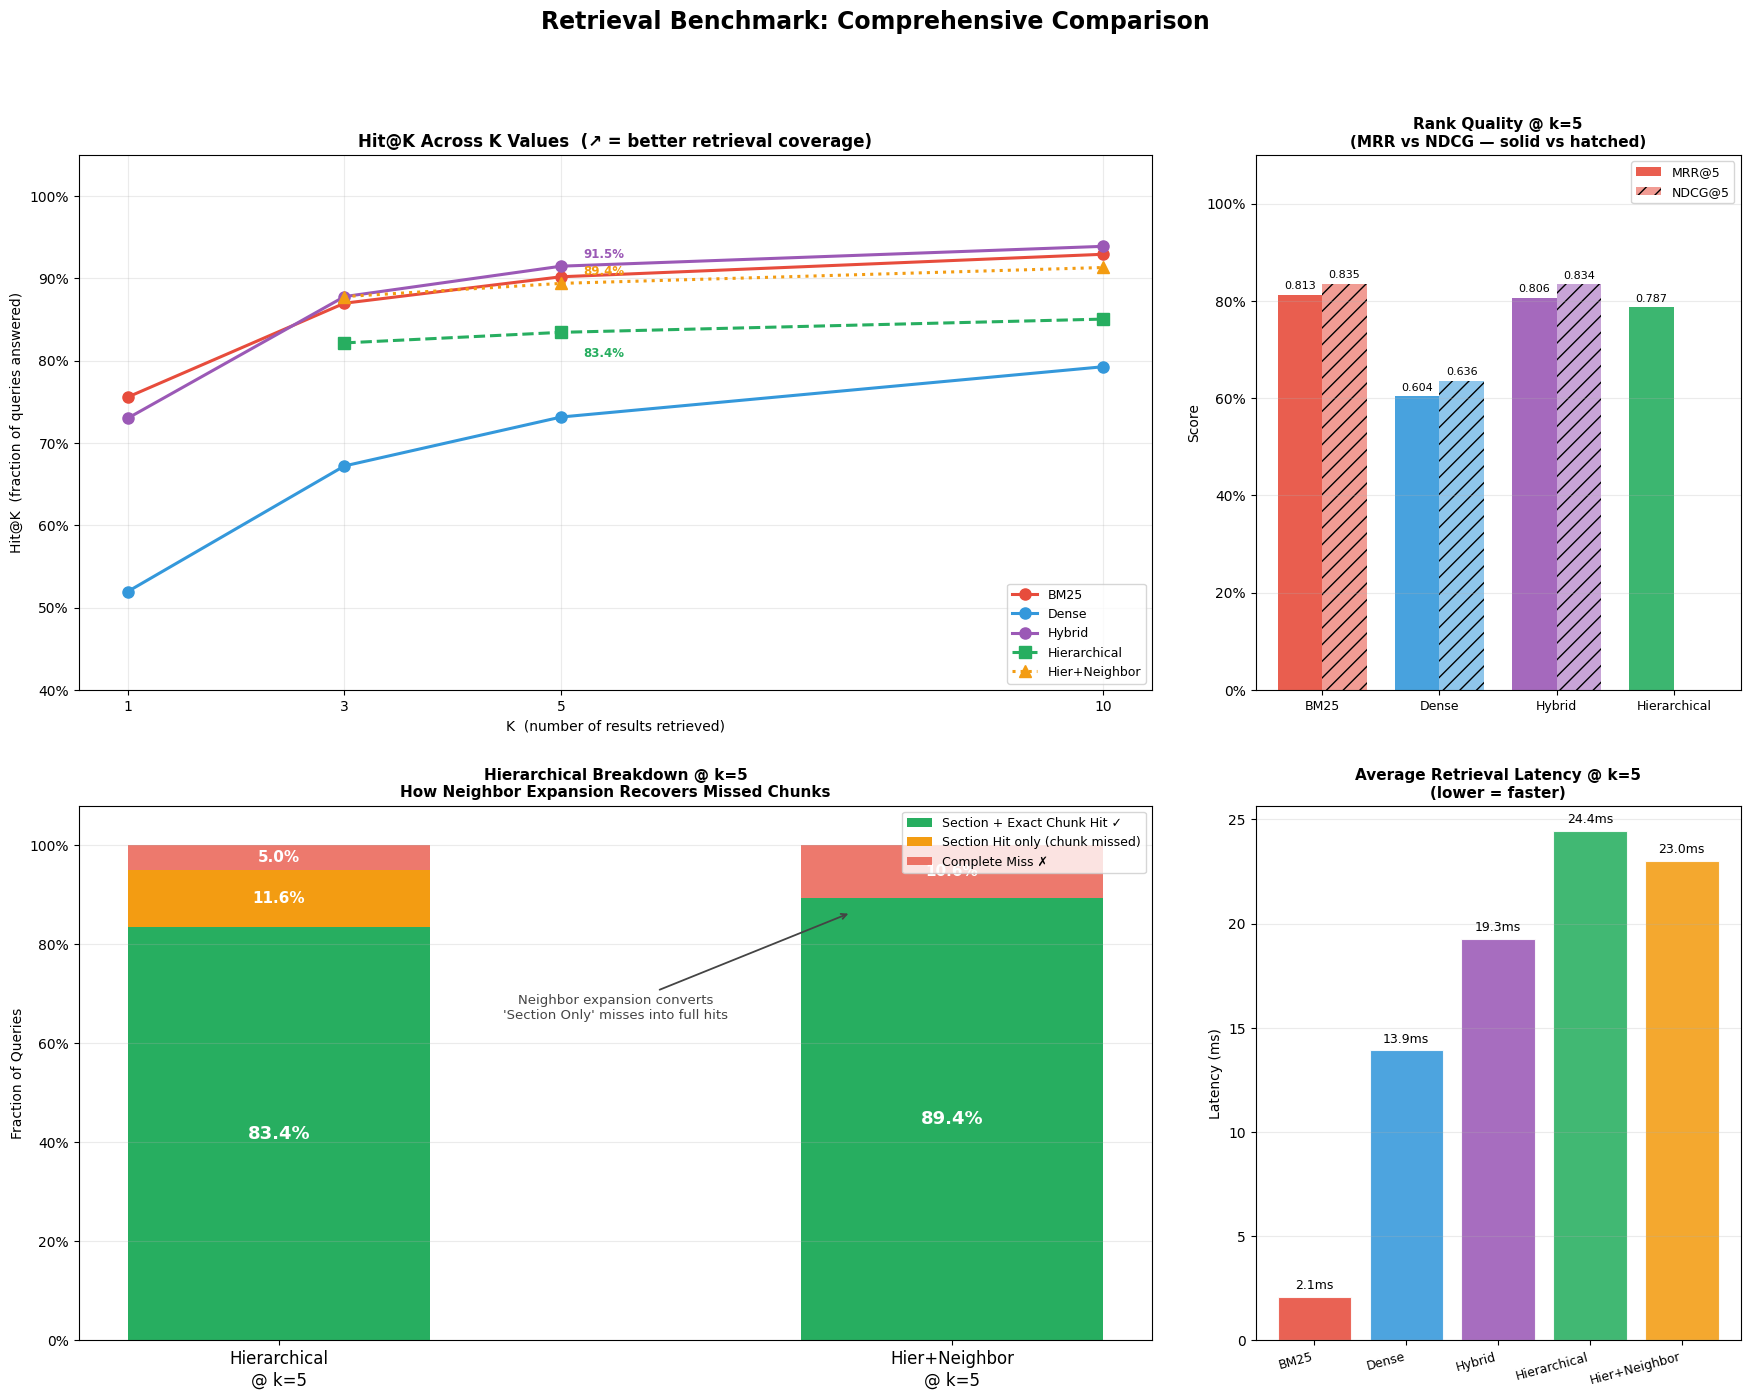

Chart saved to experiments/data/benchmark_chart.png


In [133]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

PALETTE = {
    "BM25":          "#e74c3c",
    "Dense":         "#3498db",
    "Hybrid":        "#9b59b6",
    "Hierarchical":  "#27ae60",
    "Hier+Neighbor": "#f39c12",
}

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Retrieval Benchmark: Comprehensive Comparison",
    fontsize=17, fontweight="bold", y=1.01
)

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  Panel 1 — Hit@K line chart (top-left)                                     │
# │  Shows how recall improves with K for each strategy, and where the          │
# │  improvement chain (Hybrid → Hierarchical → Hier+Neighbor) stands.         │
# └─────────────────────────────────────────────────────────────────────────────┘
ax1 = fig.add_subplot(2, 3, (1, 2))

for name in ["BM25", "Dense", "Hybrid"]:
    hits = [flat_bench[name][k]["hit_at_k"] for k in K_VALUES]
    ax1.plot(K_VALUES, hits, marker="o", label=name,
             color=PALETTE[name], linewidth=2.2, markersize=8)

hier_k  = [3, 5, 10]
ax1.plot(hier_k, [hier_bench[k]["child_hit_at_k"] for k in hier_k],
         marker="s", linestyle="--", label="Hierarchical",
         color=PALETTE["Hierarchical"], linewidth=2.2, markersize=8)
ax1.plot(hier_k, [nbr_bench[k]["child_hit_at_k"] for k in hier_k],
         marker="^", linestyle=":", label="Hier+Neighbor",
         color=PALETTE["Hier+Neighbor"], linewidth=2.2, markersize=9)

# Annotate the Hit@5 improvement chain
for name, bench, key, offset in [
    ("Hybrid",        flat_bench["Hybrid"],         "hit_at_k",       +0.01),
    ("Hierarchical",  {5: hier_bench[5]},            "child_hit_at_k", -0.03),
    ("Hier+Neighbor", {5: nbr_bench[5]},             "child_hit_at_k", +0.01),
]:
    v = bench[5][key]
    ax1.annotate(f"{v:.1%}", xy=(5, v), xytext=(5.2, v + offset),
                 fontsize=8.5, color=PALETTE[name], fontweight="bold")

ax1.set_title("Hit@K Across K Values  (↗ = better retrieval coverage)", fontsize=12, fontweight="bold")
ax1.set_xlabel("K  (number of results retrieved)")
ax1.set_ylabel("Hit@K  (fraction of queries answered)")
ax1.set_xticks(K_VALUES)
ax1.legend(fontsize=9, loc="lower right")
ax1.grid(True, alpha=0.25)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax1.set_ylim(0.4, 1.05)

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  Panel 2 — MRR & NDCG@5 (top-right)                                        │
# │  Rank-quality metrics: MRR penalises low ranks, NDCG discounts smoothly.   │
# └─────────────────────────────────────────────────────────────────────────────┘
ax2 = fig.add_subplot(2, 3, 3)

names_p2 = ["BM25", "Dense", "Hybrid", "Hierarchical"]
mrr_vals  = [flat_bench["BM25"][5]["mrr"],
             flat_bench["Dense"][5]["mrr"],
             flat_bench["Hybrid"][5]["mrr"],
             hier_bench[5]["mrr"]]
ndcg_vals = [flat_bench["BM25"][5]["ndcg_at_k"],
             flat_bench["Dense"][5]["ndcg_at_k"],
             flat_bench["Hybrid"][5]["ndcg_at_k"],
             None]

x2    = np.arange(len(names_p2))
width = 0.38
bars1 = ax2.bar(x2 - width/2, mrr_vals, width,
                label="MRR@5", color=[PALETTE[n] for n in names_p2], alpha=0.90)
bars2 = ax2.bar(x2 + width/2, [v if v is not None else 0 for v in ndcg_vals], width,
                label="NDCG@5", color=[PALETTE[n] for n in names_p2], alpha=0.55, hatch="//")

for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(bars2, ndcg_vals):
    if val is not None:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax2.set_title("Rank Quality @ k=5\n(MRR vs NDCG — solid vs hatched)", fontsize=11, fontweight="bold")
ax2.set_xticks(x2)
ax2.set_xticklabels(names_p2, fontsize=9)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel("Score")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25, axis="y")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  Panel 3 — Hierarchical breakdown stacked bars (bottom-left + mid)         │
# │  Shows exactly how Neighbor expansion converts "Section Only" hits into    │
# │  full "Sect+Child" hits — the improvement story in one view.               │
# └─────────────────────────────────────────────────────────────────────────────┘
ax3 = fig.add_subplot(2, 3, (4, 5))

h5 = hier_bench[5]
n5 = nbr_bench[5]

categories = ["Hierarchical\n@ k=5", "Hier+Neighbor\n@ k=5"]
sect_child = [h5["section_and_child_hit"],  n5["child_hit_at_k"]]
sect_only  = [h5["section_only_hit"],       0]
miss_vals  = [h5["complete_miss"],          1 - n5["child_hit_at_k"]]

x3 = np.arange(len(categories))
w3 = 0.45

b1 = ax3.bar(x3, sect_child, w3, label="Section + Exact Chunk Hit ✓",  color="#27ae60")
b2 = ax3.bar(x3, sect_only,  w3, bottom=sect_child,
             label="Section Hit only (chunk missed)", color="#f39c12")
bottom2 = [s + o for s, o in zip(sect_child, sect_only)]
b3 = ax3.bar(x3, miss_vals,  w3, bottom=bottom2,
             label="Complete Miss ✗", color="#e74c3c", alpha=0.75)

for bar, val in zip(b1, sect_child):
    if val > 0.03:
        ax3.text(bar.get_x() + bar.get_width()/2, val/2,
                 f"{val:.1%}", ha="center", va="center",
                 fontsize=13, color="white", fontweight="bold")

for bar, val, bot in zip(b2, sect_only, sect_child):
    if val > 0.03:
        ax3.text(bar.get_x() + bar.get_width()/2, bot + val/2,
                 f"{val:.1%}", ha="center", va="center",
                 fontsize=11, color="white", fontweight="bold")

for bar, val, bot in zip(b3, miss_vals, bottom2):
    if val > 0.01:
        ax3.text(bar.get_x() + bar.get_width()/2, bot + val/2,
                 f"{val:.1%}", ha="center", va="center",
                 fontsize=11, color="white", fontweight="bold")

ax3.annotate(
    "Neighbor expansion converts\n'Section Only' misses into full hits",
    xy=(0.85, sect_child[1] - 0.03), xytext=(0.5, 0.65),
    fontsize=9.5, color="#444",
    arrowprops=dict(arrowstyle="->", color="#444", lw=1.3),
    ha="center"
)

ax3.set_title(
    "Hierarchical Breakdown @ k=5\n"
    "How Neighbor Expansion Recovers Missed Chunks",
    fontsize=11, fontweight="bold"
)
ax3.set_xticks(x3)
ax3.set_xticklabels(categories, fontsize=12)
ax3.set_ylabel("Fraction of Queries")
ax3.set_ylim(0, 1.08)
ax3.legend(fontsize=9, loc="upper right")
ax3.grid(True, alpha=0.25, axis="y")
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  Panel 4 — Average retrieval latency (bottom-right)                        │
# └─────────────────────────────────────────────────────────────────────────────┘
ax4 = fig.add_subplot(2, 3, 6)

lat_names = ["BM25", "Dense", "Hybrid", "Hierarchical", "Hier+Neighbor"]
lats = [
    flat_bench["BM25"][5]["avg_latency_ms"],
    flat_bench["Dense"][5]["avg_latency_ms"],
    flat_bench["Hybrid"][5]["avg_latency_ms"],
    hier_bench[5]["avg_latency_ms"],
    nbr_bench[5]["avg_latency_ms"],
]
colors = [PALETTE[n] for n in lat_names]
bars4  = ax4.bar(lat_names, lats, color=colors, alpha=0.88, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars4, lats):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(lats)*0.01,
             f"{val:.1f}ms", ha="center", va="bottom", fontsize=9)

ax4.set_title("Average Retrieval Latency @ k=5\n(lower = faster)", fontsize=11, fontweight="bold")
ax4.set_ylabel("Latency (ms)")
ax4.set_xticklabels(lat_names, rotation=15, ha="right", fontsize=9)
ax4.grid(True, alpha=0.25, axis="y")

plt.tight_layout(pad=2.5)
plt.savefig("experiments/data/benchmark_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to experiments/data/benchmark_chart.png")